In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
%cd /content/drive/MyDrive/Colab Notebooks/TESI/MCMC_active_guided

/content/drive/MyDrive/Colab Notebooks/TESI/MCMC_active_guided


In [3]:
!pip install tinyDA

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 28.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 37.9 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: arviz
    Found existing installation: arviz 0.21.0
    Uninstalling arviz-0.21.0:
      Successfully uninstalled arviz-0.21.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.4 which is incompatible.


In [4]:
!pip install ray

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.5/68.5 MB 15.7 MB/s eta 0:00:00


In [5]:
!pip install GPy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 79.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.2/103.2 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.4/38.4 MB 21.5 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.15.3
    Uninstalling scipy-1.15.3:
      Successfully uninstalled scipy-1.15.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tsfresh 0.21.0 requires scipy>=1.14.0; python_version >= "3.10", but you have scipy 1.12.0 which is incompatible.


In [2]:
PROJECT_PATH = "/content/drive/MyDrive/Colab Notebooks/TESI/MCMC_active_guided"

import sys
sys.path.append(f"{PROJECT_PATH}/utils")

from preprocessing import preprocessing

In [3]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import modelF

from modelF import coarse_model
from scipy.stats.qmc import LatinHypercube
from scipy.stats import norm

In [4]:
nsamples_train = 50
nsamples = 1000

num_dimensions = 3  # Number of parameters
seed = 449
sampler = LatinHypercube(d=3, seed=seed)
lhs_samples = sampler.random(n=nsamples)

# Scale the samples to the desired ranges for each parameter
param_ranges = [(0.1, 0.5), (-0.5, 0.5), (29, 31)]  # Define ranges for each parameter
random_parameters = lhs_samples.copy()
for i, (low, high) in enumerate(param_ranges):
    random_parameters[:, i] = low + (high - low) * lhs_samples[:, i]


In [5]:
X_train = np.array([random_parameters[i] for i in range(nsamples_train)])
X_test = np.array([random_parameters[i] for i in range(nsamples_train, nsamples)])
Y_train = np.array([coarse_model(X_train[i]) for i in range(nsamples_train)])  # (640, 150)
Y_test = np.array([coarse_model(X_test[i]) for i in range(nsamples-nsamples_train)])  # (640, 150)

La log-likelihood usata è:

$$
\log \mathcal{L}(\theta) = -\frac{1}{2\sigma^2} \| y_{\text{obs}} - \mathcal{M}(\theta) \|^2
$$

In [6]:
def compute_log_likelihoods(Y_sim, y_obs, sigma):
    residuals = Y_sim - y_obs  # (N, T)
    squared_error = np.sum(residuals**2, axis=1)
    logL = -0.5 / sigma**2 * squared_error
    return logL

In [7]:
theta_true = np.array([0.3, 0.1, 30.2])
y_obs = coarse_model(theta_true)
sigma = 0.5

logL_train = compute_log_likelihoods(Y_train, y_obs, sigma)
logL_test = compute_log_likelihoods(Y_test, y_obs, sigma)

Ora passiamo all'allenamento del GP

### 📌 Kernel usato per il Gaussian Process

Il kernel scelto è il **kernel RBF (Radial Basis Function)**, detto anche **Squared Exponential**, ed è definito come:

$$
k(\theta, \theta') = \sigma_f^2 \exp\left( -\frac{1}{2\ell^2} \| \theta - \theta' \|^2 \right)
$$

Dove:

- sigma_f²: varianza del processo → controlla l’ampiezza delle fluttuazioni del GP  
- l (length-scale): controlla la regolarità della funzione appresa dal GP (più è grande, più la funzione è liscia)

Questo kernel è usato per modellare funzioni continue, lisce, e non periodiche — ed è quello adottato nel paper per approssimare la log-likelihood.


In [8]:
import GPy

X_train_mean = np.mean(X_train, axis=0)
X_train_std = np.std(X_train, axis=0)
X_train_centered = (X_train - X_train_mean)/X_train_std

logL_mean = np.mean(logL_train)
logL_std = np.std(logL_train)

logL_train_scaled = (logL_train - logL_mean) / logL_std
logL_test_scaled = (logL_test - logL_mean) / logL_std

kernel = GPy.kern.RBF(input_dim=3, variance=1.0, lengthscale=1.0)
model = GPy.models.GPRegression(X_train_centered, logL_train_scaled.reshape(-1, 1), kernel)

# Imposta rumore iniziale ragionevole
model.Gaussian_noise.variance = 1e-2
model.Gaussian_noise.unfix()

model.optimize()
print("Noise variance:", model.Gaussian_noise.variance.values[0])


Noise variance: 1.4664372780899976e-09


RMSE: 0.2434
R²:   0.9665


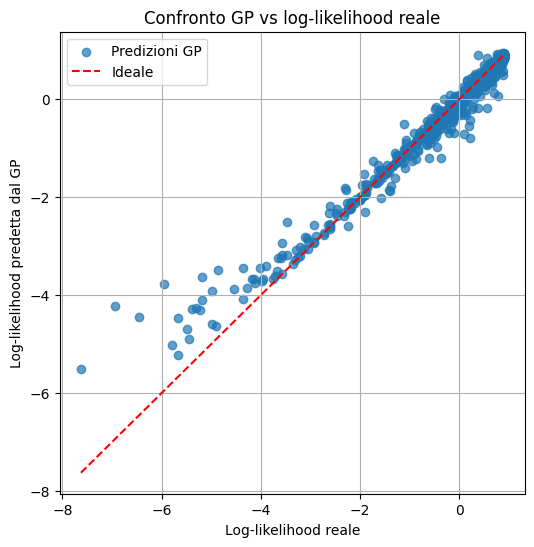

In [9]:
X_test_centered = (X_test - X_train_mean) / X_train_std

logL_pred_scaled, logL_pred_std_scaled = model.predict(X_test_centered)

from sklearn.metrics import mean_squared_error, r2_score

rmse = np.sqrt(mean_squared_error(logL_test_scaled, logL_pred_scaled))
r2 = r2_score(logL_test_scaled, logL_pred_scaled)

print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")


import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.scatter(logL_test_scaled, logL_pred_scaled, alpha=0.7, label="Predizioni GP")
plt.plot([min(logL_test_scaled), max(logL_test_scaled)], [min(logL_test_scaled), max(logL_test_scaled)], 'r--', label="Ideale")
plt.xlabel("Log-likelihood reale")
plt.ylabel("Log-likelihood predetta dal GP")
plt.title("Confronto GP vs log-likelihood reale")
plt.legend()
plt.grid(True)
plt.show()

In [10]:
print("logL_train min/max:", logL_train.min(), logL_train.max())
print("logL_test  min/max:", logL_test.min(), logL_test.max())

errors = np.linalg.norm(Y_train - y_obs, axis=1)  # Euclidean norm per ogni simulazione
print("Errore quadratico medio:", np.mean(errors**2))
print("Errore quadratico massimo:", np.max(errors**2))

logL_train min/max: -4698296.3724178225 -3423.327645331914
logL_test  min/max: -9135380.619851153 -16.165032143632022
Errore quadratico medio: 478584.59134904447
Errore quadratico massimo: 2349148.1862089112


**Procediamo con l'implementazione del seguente algoritmo:**

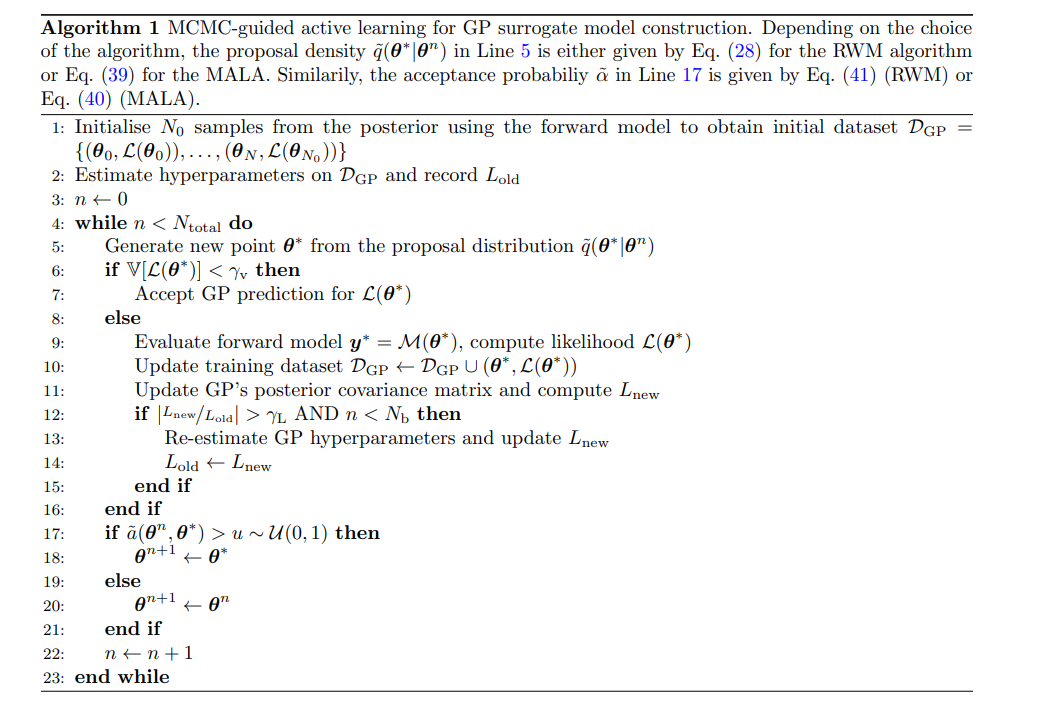

Cerchiamo di capire un valore sensato per gamma_treshold

Media delle deviazioni standard: 0.0111
Deviazione standard delle deviazioni standard: 0.0417
Valore minimo: 0.0000
Valore massimo: 0.5148


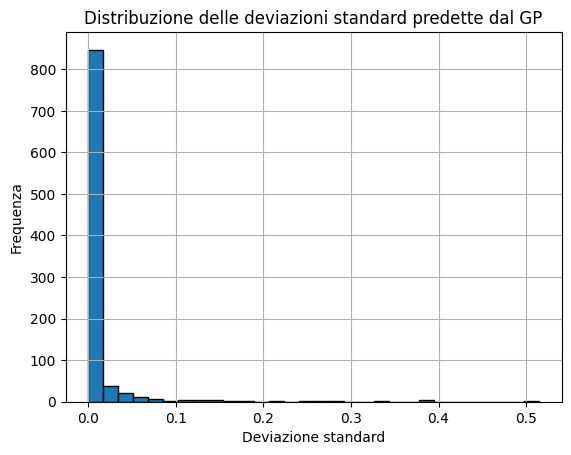

In [11]:
mu_pred, std_pred = model.predict(X_test_centered)

std_pred = std_pred.flatten()

mean_std = np.mean(std_pred)
std_std = np.std(std_pred)
min_std = np.min(std_pred)
max_std = np.max(std_pred)

print(f"Media delle deviazioni standard: {mean_std:.4f}")
print(f"Deviazione standard delle deviazioni standard: {std_std:.4f}")
print(f"Valore minimo: {min_std:.4f}")
print(f"Valore massimo: {max_std:.4f}")

plt.hist(std_pred, bins=30, edgecolor='k')
plt.title("Distribuzione delle deviazioni standard predette dal GP")
plt.xlabel("Deviazione standard")
plt.ylabel("Frequenza")
plt.grid(True)
plt.show()

Least Square per inizializzare MCMC

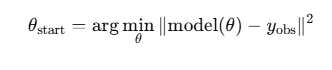

In [12]:
from scipy.optimize import least_squares

def objective_function(theta):
    y_pred = coarse_model(theta)
    return y_pred - y_obs

theta0_guess = np.mean(X_train, axis=0)

result = least_squares(objective_function, theta0_guess, bounds=([0.1, -0.5, 29], [0.5, 0.5, 31]))

theta_start = result.x
cov_matrix = np.linalg.inv(result.jac.T @ result.jac)

print(theta_start)
print(cov_matrix)

[ 0.3  0.1 30.2]
[[ 1.43622542e-04 -2.05926937e-05  1.53841461e-02]
 [-2.05926937e-05  1.29735658e-05 -4.90472277e-03]
 [ 1.53841461e-02 -4.90472277e-03  2.39036920e+00]]


In [19]:
import tinyDA as tda
import numpy as np
from numpy.random import default_rng

N_total = 1000
gamma_v = 0.04
gamma_L = 2.5
Nb = 50
s = 0.1

rng = default_rng(42)

def proposal_rwm(theta_n, cov_matrix):
    d = len(theta_n)
    z = rng.normal(0, 1, size=d)
    return theta_n + s * z

def metropolis_acceptance(logL_old, logL_new):

    return min(1.0, np.exp(logL_new - logL_old))

def active_learning_gp(model, logL_fn, forward_model,
                       X_init, logL_init, logL_mean, logL_std):
    """
    model        : GP model (GPy)
    logL_fn      : funzione log-likelihood reale (non standardizzata)
    forward_model: funzione forward (simulatore fisico)
    X_init       : (N0, d) parametri iniziali
    logL_init    : (N0,) log-likelihood reali iniziali (non standardizzate)
    logL_mean    : media della log-likelihood per standardizzazione
    logL_std     : std dev della log-likelihood per standardizzazione
    """
    D_GP = [model.X.copy(), model.Y.copy()]
    L_old = model.log_likelihood()

    theta_chain = [theta_start]
    n = 0
    retrain_counter = 0
    # cov_matrix = np.cov(X_init.T) + 1e-6 * np.eye(X_init.shape[1])

    std_history = []

    while n < N_total:
        theta_n = theta_chain[-1]
        # theta_star = proposal_rwm(theta_n, cov_matrix)
        z = np.random.multivariate_normal(mean=np.zeros(cov_matrix.shape[0]), cov=cov_matrix, size=1)
        theta_star = theta_n + s*z[0]
        print(theta_star)

        # GP prediction (input standardizzato)
        theta_star_centered = (theta_star - X_init.mean(0)) / X_init.std(0)
        mu_star, std_star = model.predict(theta_star_centered.reshape(1, -1))

        std_scalar = std_star[0, 0]

        print(f"[Iter {n}] GP std @ θ* = {std_scalar:.4f} (γ_v = {gamma_v})")
        std_history.append(std_scalar)

        if std_star[0, 0] < gamma_v:
            logL_star_scaled = mu_star[0, 0]  # accetta predizione GP
        else:
            y_star = forward_model(theta_star)
            logL_star = logL_fn(y_star)
            logL_star_scaled = (logL_star - logL_mean) / logL_std

            # aggiorna training set
            D_GP[0] = np.vstack([D_GP[0], theta_star.reshape(1, -1)])
            D_GP[1] = np.vstack([D_GP[1], [[logL_star_scaled]]])
            model.set_XY(D_GP[0], D_GP[1])

            # aggiorna log-marginal likelihood
            L_new = model.log_likelihood()
            if abs(L_new / L_old) > gamma_L and retrain_counter < Nb:
                model.optimize()
                L_old = model.log_likelihood()
                retrain_counter += 1

        # Acceptance step con logL standardizzate

        bound_1 = (theta_star[0] < 0.6)*(theta_star[0] > 0.1)
        bound_2 = (theta_star[1] < 1.0)*(theta_star[1] > -1.0)
        bound_3 = (theta_star[2] < 31.0)*(theta_star[2] > 29.0)

        theta_n_centered = (theta_n - X_init.mean(0)) / X_init.std(0)
        logL_n_scaled = model.predict(theta_n_centered.reshape(1, -1))[0][0, 0]
        logL_n_scaled = logL_n_scaled*bound_1*bound_2*bound_3
        alpha = metropolis_acceptance(logL_n_scaled, logL_star_scaled)

        if rng.uniform() < alpha:
            theta_chain.append(theta_star)
        else:
            theta_chain.append(theta_n)

        n += 1

    plt.plot(std_history)
    plt.title("Evoluzione della deviazione standard del GP")
    plt.xlabel("Iterazione")
    plt.ylabel("GP std @ proposta θ")
    plt.grid(True)
    plt.show()

    return np.array(theta_chain), D_GP


[ 0.29886457  0.10020987 30.06623073]
[Iter 0] GP std @ θ* = 0.0001 (γ_v = 0.04)
[ 0.29889404  0.10050117 29.98432538]
[Iter 1] GP std @ θ* = 0.0001 (γ_v = 0.04)
[ 0.29885315  0.10081955 29.8851415 ]
[Iter 2] GP std @ θ* = 0.0000 (γ_v = 0.04)
[ 0.29726131  0.10081575 29.76661941]
[Iter 3] GP std @ θ* = 0.0000 (γ_v = 0.04)
[ 0.29777063  0.1008481  29.7965389 ]
[Iter 4] GP std @ θ* = 0.0000 (γ_v = 0.04)
[ 0.29706612  0.10125075 29.63751949]
[Iter 5] GP std @ θ* = 0.0000 (γ_v = 0.04)
[ 0.29702095  0.10113103 29.65472714]
[Iter 6] GP std @ θ* = 0.0000 (γ_v = 0.04)
[ 0.29756413  0.10087128 29.78056599]
[Iter 7] GP std @ θ* = 0.0000 (γ_v = 0.04)
[ 0.29833944  0.10080021 29.87412752]
[Iter 8] GP std @ θ* = 0.0000 (γ_v = 0.04)
[ 0.29766989  0.10106268 29.7572563 ]
[Iter 9] GP std @ θ* = 0.0000 (γ_v = 0.04)
[ 0.29590247  0.10138504 29.55775623]
[Iter 10] GP std @ θ* = 0.0000 (γ_v = 0.04)
[ 0.29501286  0.10145401 29.46752591]
[Iter 11] GP std @ θ* = 0.0001 (γ_v = 0.04)
[ 0.29586124  0.10112972 2

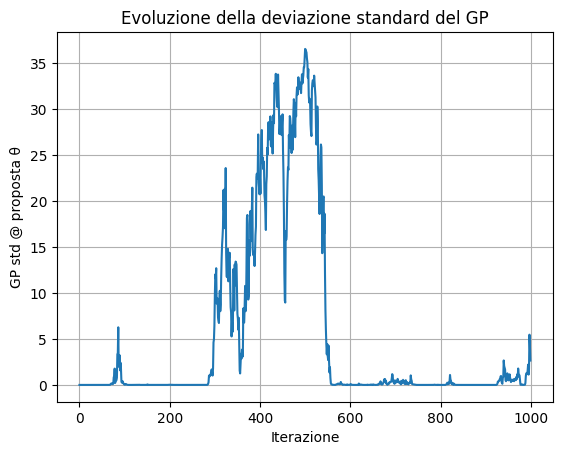

In [20]:
logL_fn = lambda y: compute_log_likelihoods(y[np.newaxis, :], y_obs, sigma)[0]

theta_chain, D_GP_final = active_learning_gp(
    model,
    logL_fn=logL_fn,       # ✅ funzione compatibile
    forward_model=coarse_model,
    X_init=X_train,
    logL_init=logL_train,
    logL_mean=logL_mean,
    logL_std=logL_std
)

**ANALISI DEI RISULTATI**

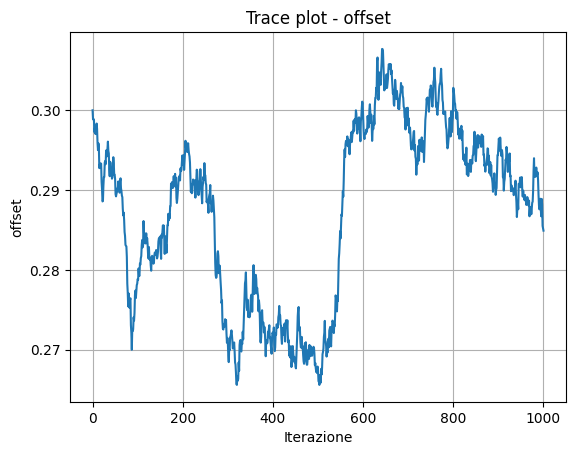

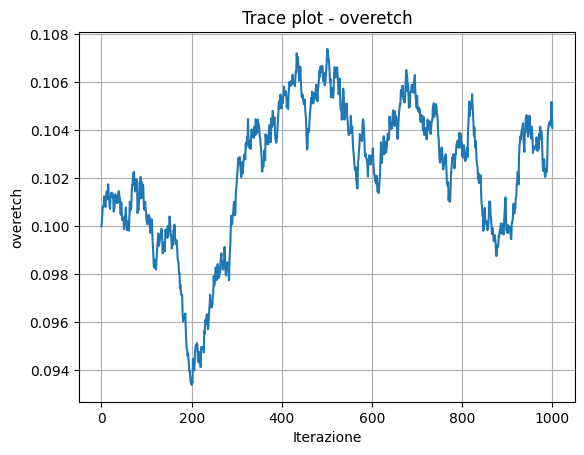

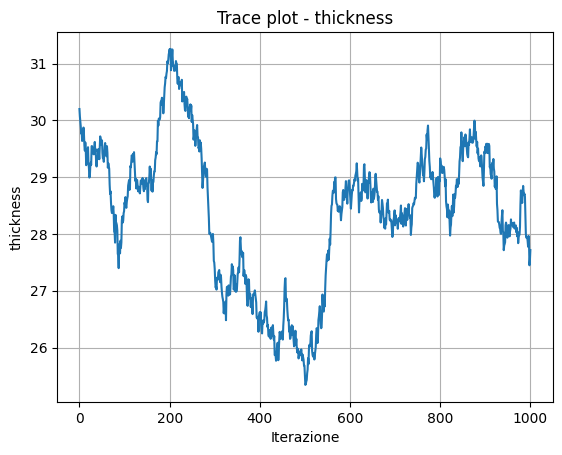

In [21]:
theta_chain = np.array(theta_chain)  # assicurati sia array (T, d)
param_names = ['offset', 'overetch', 'thickness']  # cambia se serve

for i in range(theta_chain.shape[1]):
    plt.figure()
    plt.plot(theta_chain[:, i])
    plt.title(f"Trace plot - {param_names[i]}")
    plt.xlabel("Iterazione")
    plt.ylabel(param_names[i])
    plt.grid(True)
    plt.show()

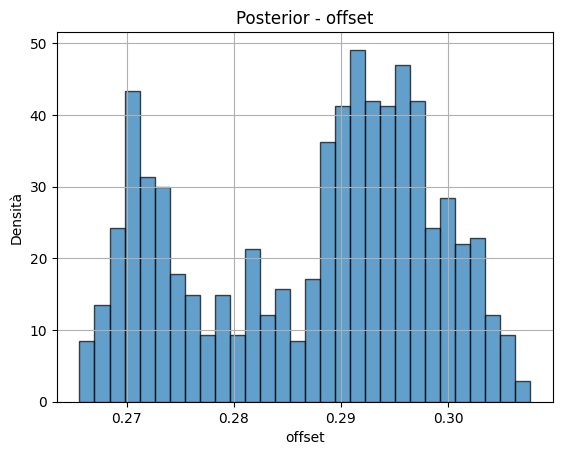

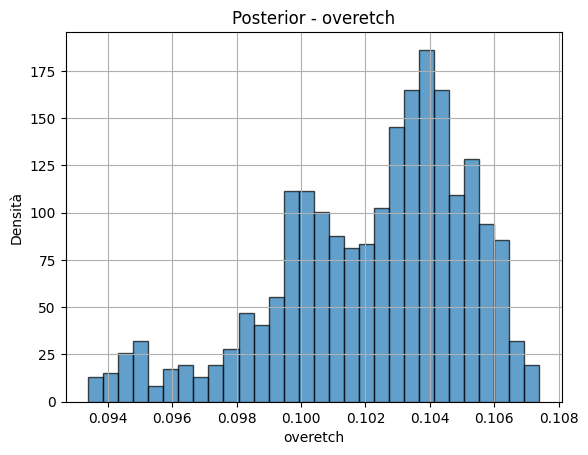

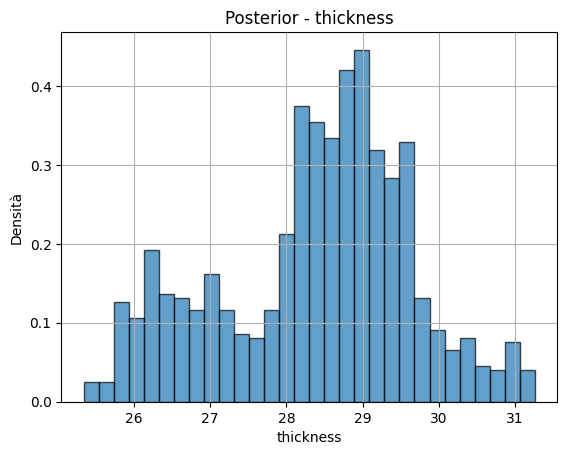

In [22]:
for i in range(theta_chain.shape[1]):
    plt.figure()
    plt.hist(theta_chain[:, i], bins=30, density=True, edgecolor='k', alpha=0.7)
    plt.title(f"Posterior - {param_names[i]}")
    plt.xlabel(param_names[i])
    plt.ylabel("Densità")
    plt.grid(True)
    plt.show()


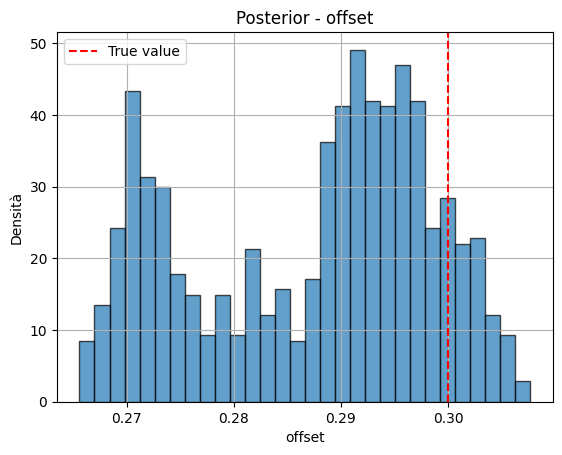

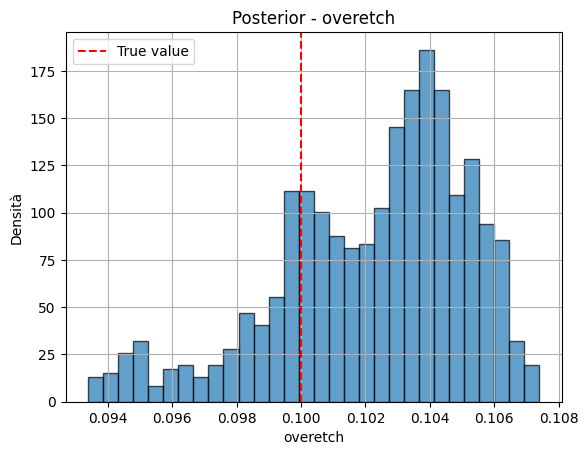

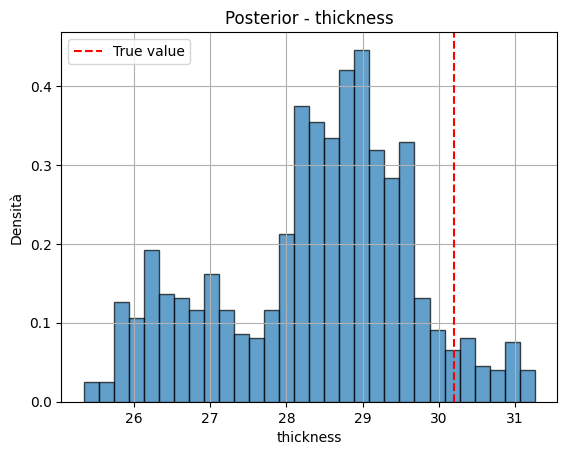

In [23]:
theta_true = np.array([0.3, 0.1, 30.2])  # esempio
for i in range(theta_chain.shape[1]):
    plt.figure()
    plt.hist(theta_chain[:, i], bins=30, density=True, edgecolor='k', alpha=0.7)
    plt.axvline(theta_true[i], color='red', linestyle='--', label='True value')
    plt.title(f"Posterior - {param_names[i]}")
    plt.xlabel(param_names[i])
    plt.ylabel("Densità")
    plt.legend()
    plt.grid(True)
    plt.show()
